<a href="https://colab.research.google.com/github/gunjancs23149/Machine-Learing-Project/blob/main/Decision_tree_CS23149.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task
Train and evaluate a Decision Tree model on the dataset found at '/content/drive/MyDrive/TG-NPDCL_consumption_detail_commercial_JANUARY-2025.csv', using both 80:20 and 70:30 train-test splits, and visualize the prediction results. The agent will identify the target variable during the data preprocessing step.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier # Assuming classification for now, might change to Regressor later
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully.")

Libraries imported successfully.


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/TG-NPDCL_consumption_detail_commercial_JANUARY-2025.csv')
print("Dataset loaded successfully. Displaying the first 5 rows:")
df.head()

Dataset loaded successfully. Displaying the first 5 rows:


,Circle,Division,SubDivision,Section,Area,CatCode,CatDesc,TotServices,BilledServices,Units,Load
0,WARANGAL,RURAL WARANGAL,WARDHANNAPET,MYLARAM,JAYARAM THANDA-1,2,COMMERCIAL,5,5,84,11.000
1,WARANGAL,WARANGAL,WARANGAL,STATION ROAD,NIZAMPURA-II,2,COMMERCIAL,392,334,44762,872.100
2,WARANGAL,WARANGAL,WARANGAL,STATION ROAD,OSMAN GANJ,2,COMMERCIAL,492,431,31931,568.730
3,WARANGAL,WARANGAL,WARANGAL,STATION ROAD,PETROL PUMP,2,COMMERCIAL,458,407,28871,657.578
4,WARANGAL,WARANGAL,WARANGAL,STATION ROAD,RAMOLLAWADA,2,COMMERCIAL,326,262,111598,2199.410


In [ ]:
print("\n--- DataFrame Info ---")
df.info()

print("\n--- Descriptive Statistics ---")
print(df.describe())

print("\n--- DataFrame Shape ---")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

print("\n--- Unique Values for Categorical Columns ---")
for column in df.select_dtypes(include='object').columns:
    print(f"Column '{column}': {df[column].nunique()} unique values")
    if df[column].nunique() < 50: # Display unique values if there aren't too many
        print(df[column].unique())
    else:
        print("Too many unique values to display all.\n")


--- DataFrame Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8335 entries, 0 to 8334
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Circle          8335 non-null   object 
 1   Division        8335 non-null   object 
 2   SubDivision     8335 non-null   object 
 3   Section         8335 non-null   object 
 4   Area            8335 non-null   object 
 5   CatCode         8335 non-null   int64  
 6   CatDesc         8335 non-null   object 
 7   TotServices     8335 non-null   int64  
 8   BilledServices  8335 non-null   int64  
 9   Units           8335 non-null   int64  
 10  Load            8335 non-null   float64
dtypes: float64(1), int64(4), object(6)
memory usage: 716.4+ KB

--- Descriptive Statistics ---
       CatCode  TotServices  BilledServices          Units          Load
count   8335.0  8335.000000     8335.000000    8335.000000   8335.000000
mean       2.0    71.645591       62.66970

### Subtask: Preprocessing and Data Splitting



In [ ]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.tree import DecisionTreeRegressor # Changing to Regressor

# Identify target variable
y = df['Units']

# Identify features to drop (single unique value, or very high cardinality)
drop_cols = ['CatCode', 'CatDesc', 'Area', 'SubDivision', 'Section']
X = df.drop(columns=['Units'] + drop_cols)

# Identify categorical and numerical columns for encoding
categorical_features = X.select_dtypes(include='object').columns.tolist() # Ensure list
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist() # Ensure list

# Create a ColumnTransformer for one-hot encoding categorical features
# Ensure sparse_output=False for OneHotEncoder to get a dense array output from ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ],
    remainder='passthrough' # Keep numerical features as they are
)

# Apply preprocessing to X
X_processed = preprocessor.fit_transform(X)

# Convert the processed data back to a DataFrame to maintain column names
# Get feature names after one-hot encoding
onehot_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)
# The remainder='passthrough' simply appends the numerical features in their original order
all_feature_names = list(onehot_feature_names) + numerical_features

X_processed_df = pd.DataFrame(X_processed, columns=all_feature_names)

print(f"Shape of X after preprocessing: {X_processed_df.shape}")

# 80:20 train-test split
X_train_80, X_test_80, y_train_80, y_test_80 = train_test_split(X_processed_df, y, test_size=0.20, random_state=42)
print(f"80:20 Split: X_train_80 shape: {X_train_80.shape}, X_test_80 shape: {X_test_80.shape}")

# 70:30 train-test split
X_train_70, X_test_70, y_train_70, y_test_70 = train_test_split(X_processed_df, y, test_size=0.30, random_state=42)
print(f"70:30 Split: X_train_70 shape: {X_train_70.shape}, X_test_70 shape: {X_test_70.shape}")

print("Data preprocessing and splitting completed successfully.")

Shape of X after preprocessing: (8335, 59)
80:20 Split: X_train_80 shape: (6668, 59), X_test_80 shape: (1667, 59)
70:30 Split: X_train_70 shape: (5834, 59), X_test_70 shape: (2501, 59)
Data preprocessing and splitting completed successfully.


## Feature Scaling



In [ ]:
scaler = StandardScaler()

# --- 80:20 Split Scaling ---
# Select numerical columns for scaling
X_train_80_numerical = X_train_80[numerical_features]
X_test_80_numerical = X_test_80[numerical_features]

# Fit on X_train_80_numerical and transform both train and test
X_train_80[numerical_features] = scaler.fit_transform(X_train_80_numerical)
X_test_80[numerical_features] = scaler.transform(X_test_80_numerical)

print("80:20 Split - Numerical features scaled. Displaying first 5 rows of X_train_80 numerical features after scaling:")
print(X_train_80[numerical_features].head())

# --- 70:30 Split Scaling ---
# Re-initialize scaler to ensure independent scaling for this split if needed, or reuse if the dataset characteristics are similar.
# For consistency and to avoid data leakage across splits, it's often best to fit a new scaler for each independent training set.
scaler_70 = StandardScaler()

# Select numerical columns for scaling
X_train_70_numerical = X_train_70[numerical_features]
X_test_70_numerical = X_test_70[numerical_features]

# Fit on X_train_70_numerical and transform both train and test
X_train_70[numerical_features] = scaler_70.fit_transform(X_train_70_numerical)
X_test_70[numerical_features] = scaler_70.transform(X_test_70_numerical)

print("\n70:30 Split - Numerical features scaled. Displaying first 5 rows of X_train_70 numerical features after scaling:")
print(X_train_70[numerical_features].head())

print("Feature scaling completed successfully for both splits.")

80:20 Split - Numerical features scaled. Displaying first 5 rows of X_train_80 numerical features after scaling:
      TotServices  BilledServices      Load
2233     5.161918        5.456363  3.914934
6798    -0.172597       -0.166034 -0.146471
3964    -0.006955       -0.002707 -0.024176
1321    -0.159855       -0.141287 -0.171001
8140    -0.295766       -0.304614 -0.266322

70:30 Split - Numerical features scaled. Displaying first 5 rows of X_train_70 numerical features after scaling:
      TotServices  BilledServices      Load
2351    -0.008589        0.020407 -0.108476
5857    -0.292457       -0.301596 -0.240710
430     -0.173150       -0.162222 -0.165545
4339    -0.169036       -0.195864 -0.155739
6946    -0.292457       -0.296790 -0.266694
Feature scaling completed successfully for both splits.


## Train Model 80:20 Split



In [ ]:
dt_regressor_80_20 = DecisionTreeRegressor(random_state=42)
dt_regressor_80_20.fit(X_train_80, y_train_80)

print("Decision Tree Regressor model for 80:20 split trained successfully.")

Decision Tree Regressor model for 80:20 split trained successfully.


**Reasoning**:
Now that the Decision Tree Regressor model for the 80:20 split has been trained, the next logical step is to use this model to make predictions on the corresponding test data. This will allow for the evaluation of the model's performance.



In [ ]:
y_pred_80_20 = dt_regressor_80_20.predict(X_test_80)

print("Predictions for 80:20 split made successfully.")

Predictions for 80:20 split made successfully.


**Reasoning**:
Now that predictions for the 80:20 split have been made, the next step is to evaluate the model's performance using standard regression metrics.



In [ ]:
mae_80_20 = mean_absolute_error(y_test_80, y_pred_80_20)
mse_80_20 = mean_squared_error(y_test_80, y_pred_80_20)
rmse_80_20 = np.sqrt(mse_80_20)
r2_80_20 = r2_score(y_test_80, y_pred_80_20)

print("--- Decision Tree Regressor Metrics (80:20 Split) ---")
print(f"Mean Absolute Error (MAE): {mae_80_20:.2f}")
print(f"Mean Squared Error (MSE): {mse_80_20:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_80_20:.2f}")
print(f"R-squared (R2): {r2_80_20:.2f}")

--- Decision Tree Regressor Metrics (80:20 Split) ---
Mean Absolute Error (MAE): 2484.45
Mean Squared Error (MSE): 41271672.12
Root Mean Squared Error (RMSE): 6424.30
R-squared (R2): 0.95


**Reasoning**:
Now that the 80:20 split model has been evaluated, I will proceed to train a Decision Tree Regressor model for the 70:30 split, using the corresponding training data (X_train_70, y_train_70).



In [ ]:
dt_regressor_70_30 = DecisionTreeRegressor(random_state=42)
dt_regressor_70_30.fit(X_train_70, y_train_70)

print("Decision Tree Regressor model for 70:30 split trained successfully.")

Decision Tree Regressor model for 70:30 split trained successfully.


**Reasoning**:
With the Decision Tree Regressor model for the 70:30 split now trained, the next step is to use this model to make predictions on the corresponding test data (`X_test_70`).



In [ ]:
y_pred_70_30 = dt_regressor_70_30.predict(X_test_70)

print("Predictions for 70:30 split made successfully.")

Predictions for 70:30 split made successfully.


**Reasoning**:
Now that predictions for the 70:30 split have been made, the next step is to evaluate the model's performance using standard regression metrics.



In [ ]:
mae_70_30 = mean_absolute_error(y_test_70, y_pred_70_30)
mse_70_30 = mean_squared_error(y_test_70, y_pred_70_30)
rmse_70_30 = np.sqrt(mse_70_30)
r2_70_30 = r2_score(y_test_70, y_pred_70_30)

print("--- Decision Tree Regressor Metrics (70:30 Split) ---")
print(f"Mean Absolute Error (MAE): {mae_70_30:.2f}")
print(f"Mean Squared Error (MSE): {mse_70_30:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_70_30:.2f}")
print(f"R-squared (R2): {r2_70_30:.2f}")

--- Decision Tree Regressor Metrics (70:30 Split) ---
Mean Absolute Error (MAE): 2344.63
Mean Squared Error (MSE): 38008440.91
Root Mean Squared Error (RMSE): 6165.10
R-squared (R2): 0.96


**Reasoning**:
Now that both models have been trained and evaluated, I will compile their performance metrics into a comparative table to easily assess which split performed better.



In [ ]:
metrics_data = {
    'Split': ['80:20', '70:30'],
    'MAE': [mae_80_20, mae_70_30],
    'MSE': [mse_80_20, mse_70_30],
    'RMSE': [rmse_80_20, rmse_70_30],
    'R2 Score': [r2_80_20, r2_70_30]
}

comparison_df = pd.DataFrame(metrics_data)

print("\n--- Decision Tree Regressor Performance Comparison ---")
print(comparison_df.round(2))


--- Decision Tree Regressor Performance Comparison ---
   Split      MAE          MSE    RMSE  R2 Score
0  80:20  2484.45  41271672.12  6424.3      0.95
1  70:30  2344.63  38008440.91  6165.1      0.96


## Visualize the actual vs. predicted 'Units' for both the 80:20 and 70:30 splits.




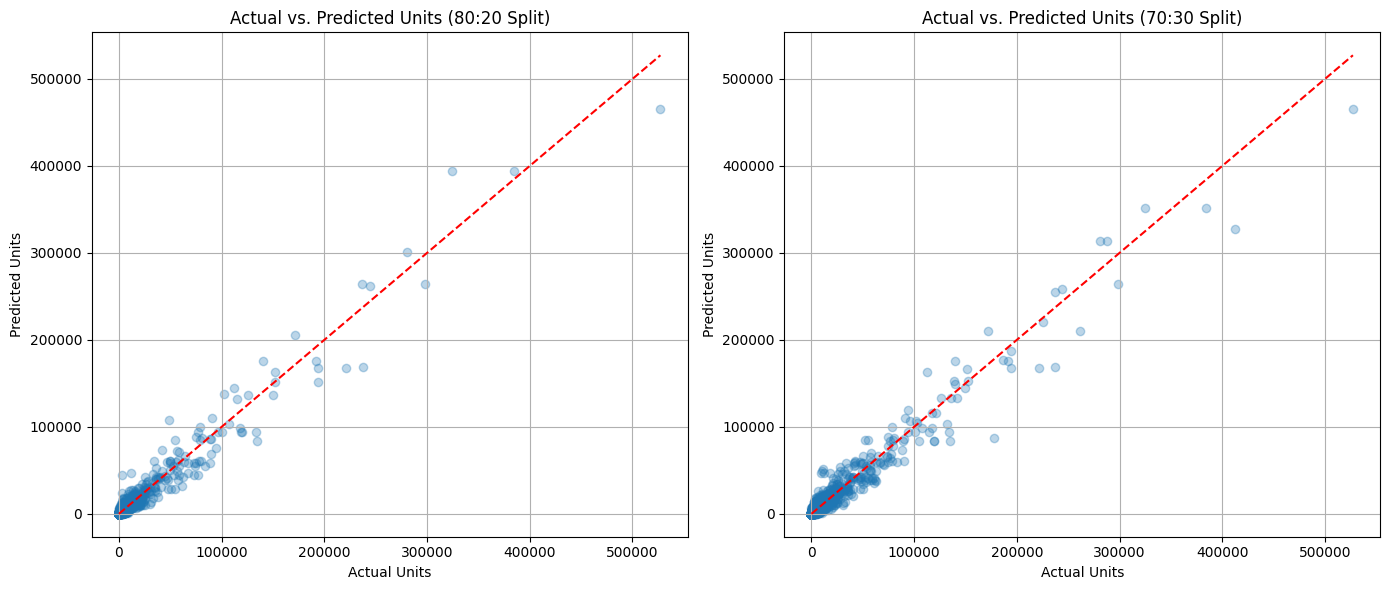

Visualizations for actual vs. predicted 'Units' completed.


In [ ]:
plt.figure(figsize=(14, 6))

# Subplot 1: 80:20 Split
plt.subplot(1, 2, 1)
plt.scatter(y_test_80, y_pred_80_20, alpha=0.3)
plt.plot([min(y_test_80), max(y_test_80)], [min(y_test_80), max(y_test_80)], color='red', linestyle='--')
plt.title('Actual vs. Predicted Units (80:20 Split)')
plt.xlabel('Actual Units')
plt.ylabel('Predicted Units')
plt.grid(True)

# Subplot 2: 70:30 Split
plt.subplot(1, 2, 2)
plt.scatter(y_test_70, y_pred_70_30, alpha=0.3)
plt.plot([min(y_test_70), max(y_test_70)], [min(y_test_70), max(y_test_70)], color='red', linestyle='--')
plt.title('Actual vs. Predicted Units (70:30 Split)')
plt.xlabel('Actual Units')
plt.ylabel('Predicted Units')
plt.grid(True)

plt.tight_layout()
plt.show()

print("Visualizations for actual vs. predicted 'Units' completed.")

## Display Metrics for 80:20 Split



In [ ]:
print("--- Decision Tree Regressor Metrics (80:20 Split) ---")
print(comparison_df[comparison_df['Split'] == '80:20'].round(2))

--- Decision Tree Regressor Metrics (80:20 Split) ---
   Split      MAE          MSE    RMSE  R2 Score
0  80:20  2484.45  41271672.12  6424.3      0.95


## Display Metrics for 70:30 Split



In [ ]:
print("--- Decision Tree Regressor Metrics (70:30 Split) ---")
print(comparison_df[comparison_df['Split'] == '70:30'].round(2))

--- Decision Tree Regressor Metrics (70:30 Split) ---
   Split      MAE          MSE    RMSE  R2 Score
1  70:30  2344.63  38008440.91  6165.1      0.96
